In [76]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent   # if notebook is inside notebooks/
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [77]:
import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
import os
from langchain_groq import ChatGroq
from src.langchain_vertex import VertexAIChat
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.checkpoint.postgres import PostgresSaver
import psycopg
from psycopg.rows import dict_row
from dotenv import load_dotenv
load_dotenv()

True

In [78]:
def get_database_url():
    database_url = os.getenv("DATABASE_URL")

    if not database_url:
        raise ValueError("DATABASE_URL is missing. Please add your Render PostgreSQL External Database URL to .env")

    if "sslmode=" not in database_url:
        separator = "&" if "?" in database_url else "?"
        database_url = f"{database_url}{separator}sslmode=require"

    return database_url

In [79]:
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY is missing. Please add it to your .env file.")
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
if not GOOGLE_API_KEY:
    raise ValueError("GOOGLE_API_KEY is missing. Please add it to your .env file.")

In [80]:
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description="What to cover")

In [81]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [82]:
class State(TypedDict):
    topic: str
    plan: Plan
    # reducer: results from workers get concatenated automatically
    sections: Annotated[List[str], operator.add]
    final: str

In [83]:
llm_groq = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=GROQ_API_KEY
)

In [84]:
#from langchain_google_genai import ChatGoogleGenerativeAI
#llm_gem = ChatGoogleGenerativeAI(
#    model="gemini-2.5-flash",
#    api_key=GOOGLE_API_KEY
#)

In [85]:
llm_vertex = VertexAIChat(model="gemini-3.5-flash",api_key=GOOGLE_API_KEY, temperature=0)

In [86]:
def orchestrator(state: State) -> dict:

    plan = llm_vertex.with_structured_output(Plan).invoke(
        [
            SystemMessage(content=("Create a blog plan with 5-7 sections on the following topic.")),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    return {"plan": plan}

In [ ]:
def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
            for task in state["plan"].tasks]

In [88]:
def worker(payload: dict) -> dict:

    # payload contains what we sent
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    section_md = llm_vertex.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}

In [89]:
from pathlib import Path

def reducer(state: State) -> dict:
    
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # ---- save to file ----
    filename = title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}

In [90]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

In [ ]:
# =========================
# PostgreSQL Checkpointer
# =========================
#from langgraph.checkpoint.postgres import PostgresSaver
#from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer

DATABASE_URL = get_database_url()

_conn = psycopg.connect(DATABASE_URL,autocommit=True,row_factory=dict_row)

# Register custom types with JsonPlusSerializer to allow msgpack deserialization
#serde = JsonPlusSerializer(
#    allowed_msgpack_modules=[
#        ("__main__", "Plan"),
#        ("__main__", "Task"),
#        ("*", "*"),
#    ]
#)

checkpointer = PostgresSaver(_conn)
checkpointer.setup()


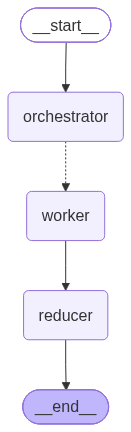

In [56]:
app = g.compile(checkpointer=checkpointer)
app

In [57]:
config = {"configurable": {"thread_id": "test_thread_id"}}

In [58]:
out = app.invoke({"topic": "Write a blog on Self Attention", "sections": []}, config=config)

In [96]:
out

{'topic': 'Write a blog on Self Attention',
 'plan': Plan(blog_title='Demystifying Self-Attention: The Engine Behind Modern AI', tasks=[Task(id=1, title='Introduction to Self-Attention', brief='Introduce the concept of self-attention, its origin in the Transformer paper, and why it revolutionized natural language processing.'), Task(id=2, title='The Intuition: Why Do We Need It?', brief='Explain how self-attention allows models to understand context by relating different words in a sentence to each other, using a simple pronoun resolution example.'), Task(id=3, title='The Core Mechanics: Queries, Keys, and Values', brief='Define the Q, K, and V vectors, explaining their roles using an analogy like a database search or library lookup system.'), Task(id=4, title='Step-by-Step Mathematical Walkthrough', brief='Break down the scaled dot-product attention formula, explaining the dot product, scaling factor, softmax activation, and final weighted sum.'), Task(id=5, title='Scaling Up: Multi-H

In [98]:
print(out['final'])

# Demystifying Self-Attention: The Engine Behind Modern AI

## Introduction to Self-Attention

In the rapidly evolving landscape of deep learning, few innovations have had as profound an impact as the **Self-Attention mechanism**. At its core, self-attention is a mechanism that allows a machine learning model to relate different positions of a single sequence in order to compute a representation of that sequence. It enables a model to dynamically focus on the most relevant parts of the input data, regardless of how far apart they are.

To understand this intuitively, consider the sentence: *"The animal didn't cross the street because it was too tired."* As humans, we instantly know that the word "it" refers to the "animal," not the "street." Self-attention allows a neural network to make this exact connection by calculating how much "attention" the word "it" should pay to every other word in the sentence, effectively mapping out the contextual relationships within the text.

### Why is

In [99]:
out['plan']

Plan(blog_title='Demystifying Self-Attention: The Engine Behind Modern AI', tasks=[Task(id=1, title='Introduction to Self-Attention', brief='Introduce the concept of self-attention, its origin in the Transformer paper, and why it revolutionized natural language processing.'), Task(id=2, title='The Intuition: Why Do We Need It?', brief='Explain how self-attention allows models to understand context by relating different words in a sentence to each other, using a simple pronoun resolution example.'), Task(id=3, title='The Core Mechanics: Queries, Keys, and Values', brief='Define the Q, K, and V vectors, explaining their roles using an analogy like a database search or library lookup system.'), Task(id=4, title='Step-by-Step Mathematical Walkthrough', brief='Break down the scaled dot-product attention formula, explaining the dot product, scaling factor, softmax activation, and final weighted sum.'), Task(id=5, title='Scaling Up: Multi-Head Attention', brief='Explain why we use multiple at